![MLU Logo](https://drive.corp.amazon.com/view/bwernes@/MLU_Logo.png?download=true)

# <a name="0">MATH - Lecture 2 - 02 - Linear Regression (OLS)</a>

* <a href="#99">ML Business Problem: Regression</a> (predict chechout amount)


* <a href="#1">Linear Regression</a>
* <a href="#2">Ordinary Least Squares (OLS)</a>
* <a href="#3">Ordinary Least Squares (OLS) sklearn Implementation</a>
* <a href="#4">Nonlinear OLS and Regularization</a>
* <a href="#5">OLS Complexity and Multicollinearity</a>
    
    
* <a href="#100">Summary</a>


###Instalando librerias

In [ ]:
# Upgrade dependencies
#!pip install --upgrade pip
#!pip install --upgrade scikit-learn

# Import our standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math as math
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


## <a name="99">¿Checkout Amount?</a>
(<a href="#0">Go to top</a>)

Un gerente del departamento de jardinería quiere analizar y predecir cuánto gastará un cliente (Checkout Amount) cuando visita la página de productos de jardinería.
Para eso, tiene datos históricos de los clientes, como:

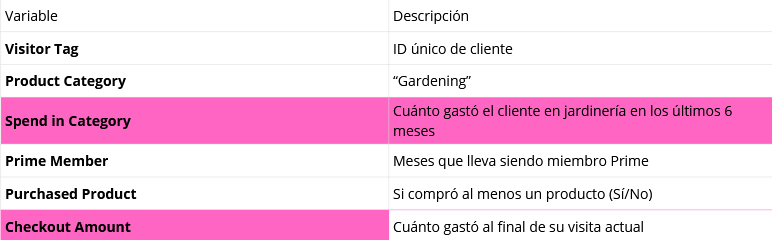


Objetivo: Predecir el “Checkout Amount” (cantidad gastada al final de la visita)
en función de “Spend in Category” (cuánto ha gastado el cliente en los últimos 6 meses).



#### 1.- Cargar los datos y seleccionar columnas relevantes

---



Data Loading and Data Splitting

In [ ]:
from google.colab import files

uploaded = files.upload()


data = pd.read_csv('MATH_Lecture_2_Data.csv')
print('Shape of the dataset:', data.shape)
data.head()


Saving MATH_Lecture_2_Data.csv to MATH_Lecture_2_Data (1).csv
Shape of the dataset: (83, 6)


,Customer ID,Product Category,Spend in Category,Prime Member,Purchased Product,Checkout Amount
0,84920394,A8B44391,0.0,0,0,0.0
1,84223934,A8B44391,70.0,42,1,156.0
2,83202384,A8B44391,30.0,15,0,0.0
3,84342229,A8B44391,45.0,12,1,79.0
4,8339332,A8B44391,0.0,3,0,0.0


### 3.-Dividir en entrenamiento y prueba
___


In [ ]:
columns = ['Spend in Category', 'Prime Member', 'Purchased Product', 'Checkout Amount']

features_columns = ['Spend in Category']
#features_columns = ['Spend in Category', 'Prime Member']
#features_columns = ['Spend in Category', 'Prime Member', 'Purchased Product']
target_column = 'Checkout Amount'

features = data[features_columns].values
labels = data[target_column].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, labels, random_state = 0)

print('Shape of the training dataset:', X_train.shape)
print('Shape of the test dataset:', X_test.shape)

y_train, y_test = y_train.reshape(-1,1), y_test.reshape(-1,1)
print('Shape of the training and test labels:', y_train.shape, y_test.shape)

x_new = np.array([65, 33, 0])
x_new = x_new[0:len(features_columns)].reshape(1,-1)
print('Shape of new datapoint:', x_new.shape)


Shape of the training dataset: (62, 1)
Shape of the test dataset: (21, 1)
Shape of the training and test labels: (62, 1) (21, 1)
Shape of new datapoint: (1, 1)


#### 4.- Escalar los datos
---
Data Scaling

In [ ]:
# Scale the dataset
from sklearn.preprocessing import StandardScaler
scl = StandardScaler()
X_train = scl.fit_transform(X_train)
X_test = scl.transform(X_test)
x_new = scl.transform(x_new.reshape(1,-1))[0]


## <a name="1">Regresión lineal</a>




###Función para gráficar
---


We can propose a few linear models, and analyse their performance.

In [ ]:
def plot_data_model(X, y, intercept, slope, R2):
    plt.figure(figsize=(18,6))
    for i in range(len(features_columns)):
        plt.subplot(1,3,i+1)
        train = plt.scatter(X[:,i], y, c = 'tab:blue', alpha = 0.5)
        plt.plot((x_new[i], x_new[i]), (np.min(y), np.max(y)), '--', color = 'tab:red')

        x0 = np.linspace(np.min(X[:,i]), np.max(X[:,i]), X[:,i].shape[0]).reshape(-1,1)
        plt.title('Proposed model parameters: intercept = {}, slope = {}'.format(intercept, slope))
        y0 = x0*slope + intercept
        #plt.plot(x0,y0, '-', color = 'darkorange')
        baseline = plt.scatter(x0[:],y0[:], color = 'darkorange', lw = .1)

        plt.xlabel(features_columns[i])
        plt.ylabel('Checkout Amount')
        plt.legend((train, baseline), ('true values', 'linear model predictions (R2 test = {0:.2f})'.format(R2)),
                   loc = 'upper left')


###Métricas de regresión lineal, graficas y predicciones
____

Linear model prediction for x_new = [1.37554349] is: [113.75543494]
Linear model Training R2 = 0.12
Linear model Test R2 = 0.11


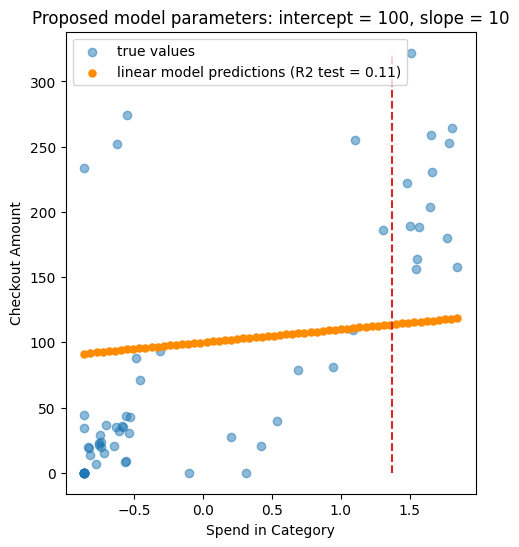

Linear model prediction for x_new = [1.37554349] is: [118.77717472]
Linear model Training R2 = 0.38
Linear model Test R2 = 0.54


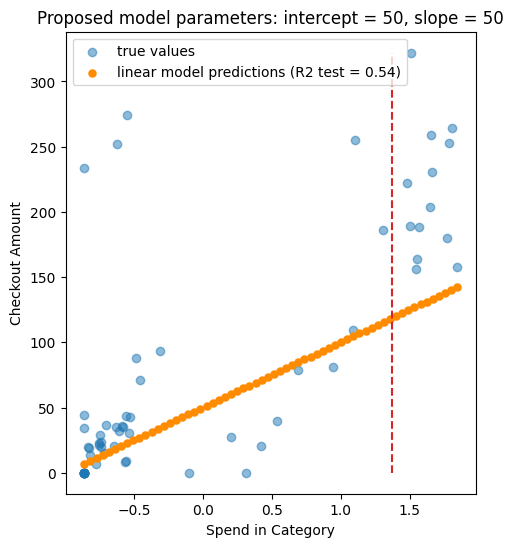

In [ ]:
# Regression Metrics - compare to sklearn implementation
# from sklearn.metrics import r2_score, mean_squared_error
def Regression_Metrics(y_true, y_predict):
    #print((y_true-y_predict).shape) # check shape #print((y_true-y_predict).shape) for broadcasting !!!
    MSE = np.mean((y_true-y_predict)**2)
    BMSE = np.mean((y_true-np.mean(y_true))**2)
    R2 = 1.0-(MSE/BMSE)
    return MSE, np.sqrt(MSE), R2

# Propose some linear regression solutions
proposed_models = np.array([[100, 10], [50, 50]])

for model in proposed_models:
    intercept, slope = model[0], model[1]

    print('Linear model prediction for x_new = {} is: {}'.format(x_new, x_new*slope + intercept))

    train_predictions = X_train*slope + intercept
    MSE, RMSE, R2 = Regression_Metrics(y_train, train_predictions)
    print('Linear model Training R2 = {0:.2f}'.format(R2))
    #print('Linear model Training metrics: MSE = {}. RMS = {}, R2 = {}'.format(MSE, RMSE, R2))

    test_predictions = X_test*slope + intercept
    MSE, RMSE, R2 = Regression_Metrics(y_test, test_predictions)
    print('Linear model Test R2 = {0:.2f}'.format(R2))
    #print('Linear model Test metrics: MSE = {}. RMS = {}, R2 = {}'.format(MSE, RMSE, R2))

    plot_data_model(X_train, y_train, intercept, slope, R2)
    plt.show()


## <a name="2">Regresión lineal por mínimos cuadrados (OLS)</a>
___

Ordinary Least Squares (OLS)


###Implementación manual de la Regresión Lineal (OLS)

In [ ]:
# OLS Regression solution
def OLS(X_train, y_train):
    X_a = np.concatenate((np.ones((X_train.shape[0],1)), X_train),axis=1)
    return np.linalg.inv(X_a.T.dot(X_a)).dot(X_a.T.dot(y_train)).reshape(-1,1)

OLSmodel = OLS(X_train, y_train)
print('OLS model parameters:\n', OLSmodel)

x_new = x_new.reshape(1, -1)
x_new_a = np.concatenate((np.ones((x_new.shape[0],1)), x_new),axis=1)
print('OLS prediction for x_new = {} is: {}'.format(x_new, x_new_a.dot(OLSmodel)))

X_train_a = np.concatenate((np.ones((X_train.shape[0],1)), X_train),axis=1)
train_predictions = X_train_a.dot(OLSmodel)
MSE, RMSE, R2 = Regression_Metrics(y_train, train_predictions)
print('OLS Training R2 = {0:.2f}'.format(R2))
#print('OLS Training metrics: MSE = {}. RMS = {}, R2 = {}'.format(MSE, RMSE, R2))

X_test_a = np.concatenate((np.ones((X_test.shape[0],1)), X_test),axis=1)
test_predictions = X_test_a.dot(OLSmodel)
MSE, RMSE, R2 = Regression_Metrics(y_test, test_predictions)
print('OLS Test R2 = {0:.2f}'.format(R2))
#print('OLS Test metrics: MSE = {}. RMS = {}, R2 = {}'.format(MSE, RMSE, R2))


OLS model parameters:
 [[83.84937559]
 [70.44040584]]
OLS prediction for x_new = [[1.37554349]] is: [[180.74321759]]
OLS Training R2 = 0.56
OLS Test R2 = 0.76


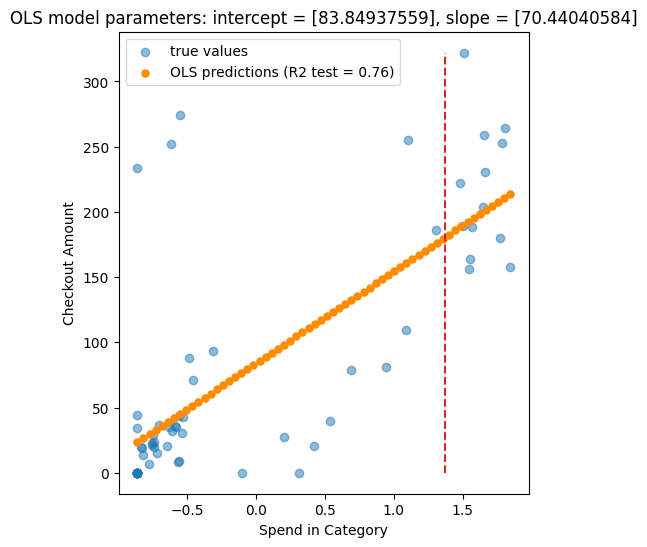

In [ ]:
def plot_data_OLSmodel(X, y, X_test):
    plt.figure(figsize=(18, 6))
    for i in range(len(features_columns)):
        plt.subplot(1,3,i+1)
        train = plt.scatter(X[:,i], y, c = 'tab:blue', alpha = 0.5)
        plt.plot((x_new[i], x_new[i]), (np.min(y), np.max(y)), '--', color = 'tab:red')

        x0 = np.linspace(np.min(X[:,i]), np.max(X[:,i]), X[:,i].shape[0]).reshape(-1,1)
        w = OLS(X[:,i].reshape(-1,1), y_train)
        slope, intercept = w[1], w[0] # OLS model
        #slope, intercept = 83, 70 # propose some linear model
        y0 = x0*slope + intercept
        #plt.plot(x0,y0, '-', color = 'darkorange')
        baseline = plt.scatter(x0[:],y0[:], color = 'darkorange', lw = .1)
        plt.title('OLS model parameters: intercept = {}, slope = {}'.format(intercept, slope))
        plt.xlabel(features_columns[i])
        plt.ylabel('Checkout Amount')
        plt.legend((train, baseline), ('true values', 'OLS predictions (R2 test = {0:.2f})'.format(R2)), loc = 'upper left')


plot_data_OLSmodel(X_train, y_train, x_new)
plt.show()


###Implementación de la Regresión Lineal (OLS) con sklearn


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

OLS_sklearn = LinearRegression()
OLS_sklearn.fit(X_train, y_train)
print('sklearn LinearRegression model parameters:', OLS_sklearn.intercept_, OLS_sklearn.coef_)
print('sklearn LinearRegression model parameters #:', len(OLS_sklearn.intercept_)+len(OLS_sklearn.coef_) )

print('sklearn LinearRegression prediction for x_new = {} is: {}'.format(x_new, OLS_sklearn.predict(x_new.reshape(-1, 1))))
print('sklearn LinearRegression Training R2: {0:.2f}'.format(r2_score(y_train, OLS_sklearn.predict(X_train))))
print('sklearn LinearRegression Test R2: {0:.2f}'.format(r2_score(y_test, OLS_sklearn.predict(X_test))))


sklearn LinearRegression model parameters: [83.84937559] [[70.44040584]]
sklearn LinearRegression model parameters #: 2
sklearn LinearRegression prediction for x_new = [[1.37554349]] is: [[180.74321759]]
sklearn LinearRegression Training R2: 0.56
sklearn LinearRegression Test R2: 0.76


## <a name="4">Nonlineal OLS y Regularización</a>
___
Nonlinear OLS and Regularization


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(7)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

OLS_sklearn_poly = LinearRegression()
OLS_sklearn_poly.fit(X_train_poly, y_train)
print('sklearn LinearRegression with PolynomialFeatures model parameters:\n', OLS_sklearn_poly.intercept_, OLS_sklearn_poly.coef_)
print('sklearn LinearRegression with PolynomialFeatures model parameters #:', len(OLS_sklearn_poly.intercept_)+len(OLS_sklearn_poly.coef_[0]) )

print('sklearn LinearRegression with PolynomialFeatures Training R2: {0:.2f}'.format(r2_score(y_train, OLS_sklearn_poly.predict(X_train_poly))))
print('sklearn LinearRegression with PolynomialFeatures Test R2: {0:.2f}'.format(r2_score(y_test, OLS_sklearn_poly.predict(X_test_poly))))
print('\n')

from sklearn.linear_model import Ridge
best_alpha, best_r2 = 0.0, 0.0
for i in range(100):
    alpha = i*0.01
    Ridge_poly = Ridge(alpha=alpha)
    Ridge_poly.fit(X_train_poly, y_train)
    r2 = r2_score(y_test, Ridge_poly.predict(X_test_poly))
    if r2 > best_r2:
        best_r2 = r2
        best_alpha = alpha
print('Best regularizer: {}; best R2: {}'.format(best_alpha, best_r2))

Ridge_poly = Ridge(alpha=best_alpha)
Ridge_poly.fit(X_train_poly, y_train)
print('sklearn Ridge with PolynomialFeatures model parameters:\n', Ridge_poly.intercept_, Ridge_poly.coef_)
print('sklearn Ridge with PolynomialFeatures model parameters #:', len(OLS_sklearn_poly.intercept_)+len(OLS_sklearn_poly.coef_[0]) )

print('sklearn Ridge with PolynomialFeatures Training R2: {0:.2f}'.format(r2_score(y_train, Ridge_poly.predict(X_train_poly))))
print('sklearn Ridge with PolynomialFeatures Test R2: {0:.2f}'.format(r2_score(y_test, Ridge_poly.predict(X_test_poly))))


sklearn LinearRegression with PolynomialFeatures model parameters:
 [20.43185925] [[   0.         -167.74363931  242.63935121  556.27451835 -536.23523774
  -265.63359744  402.46855561 -107.41494815]]
sklearn LinearRegression with PolynomialFeatures model parameters #: 9
sklearn LinearRegression with PolynomialFeatures Training R2: 0.65
sklearn LinearRegression with PolynomialFeatures Test R2: 0.73


Best regularizer: 0.05; best R2: 0.8244915867105741
sklearn Ridge with PolynomialFeatures model parameters:
 [35.32183187] [  0.         -69.37972118  70.51389503 181.0990092  -52.56400191
 -39.20706097  -3.46344827   6.95759141]
sklearn Ridge with PolynomialFeatures model parameters #: 9
sklearn Ridge with PolynomialFeatures Training R2: 0.64
sklearn Ridge with PolynomialFeatures Test R2: 0.82


## <a name="5">OLS complejidad y Multicolinealidad</a>
___
OLS Complexity and Multicollinearity

Complejidad de OLS
El problema es que invertir una matriz es computacionalmente costoso.
Modelos muy grandes o con muchas columnas aumentan la complejidad computacional.
+ columnas en un modelo = =  + lento y pesado


Multicolinealidad
Ocurre cuando algunas variables del modelo están altamente correlacionadas entre sí.
Cuando dos columnas están altamente correlacionadas, una es casi una combinación lineal de la otra.
Entonces las columnas no son linealmente independientes porque su determinante = 0 (o muy cercano a 0). y eso significa que  no se puede invertir:
Matemáticamente, decimos que la matriz está “singular” o “mal condicionada”

¿Cómo se soluciona?

Usar trucos de álgebra lineal como:

a) Descomposición de matrices
En lugar de invertir directamente la matriz, se puede descomponer en partes más pequeñas
Ej. SVD: Singular Value Decomposition
Y puedes encontrar una “pseudoinversa” estable para resolver el sistema sin que explote por multicolinealidad.
 Esto es lo que internamente hace sklearn.LinearRegression().


b) Cambio de base
Es transformar el conjunto de datos a un nuevo sistema de coordenadas donde las variables estén descorrelacionada
Se logra con Principal Component Analysis (PCA).
obtienes nuevas columnas que son combinaciones lineales de las originales, pero no correlacionadas
Principal Components Regression (PCR).
Después puedes hacer regresión sobre esas nuevas variables:
Ventaja:
Reduce la multicolinealidad y la complejidad computacional
Te permite usar menos componentes que variables originales, sin perder mucha información.

# End of Notebook

![MLU Logo](https://drive.corp.amazon.com/view/bwernes@/MLU_Logo.png?download=true)